# Seaborn Diamonds 데이터셋 다중선형회귀

이 노트북은 **TensorFlow/Keras**와 기본 라이브러리(Pandas, NumPy, Seaborn)만을 사용하여 다이아몬드 가격(`price`)을 예측하는 딥러닝 모델을 구축하고 평가합니다. (Scikit-learn 등 다른 머신러닝 라이브러리는 사용하지 않습니다.)

In [19]:
# 셀 1: 라이브러리 임포트
import pandas as pd
import numpy as np
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.22.0-rc0


In [20]:
# 셀 2: 데이터 로드 및 탐색
df = sns.load_dataset('diamonds')
print(df.head())
print("\n데이터셋 정보:")
print(df.info())

   carat      cut color clarity  depth  table  price     x     y     z
0   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
1   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
2   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31
3   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63
4   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75

데이터셋 정보:
<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64

In [21]:
# 셀 3: 데이터 전처리 (원핫 인코딩 및 정규화)
# 1. 범주형 변수 원핫 인코딩 (cut, color, clarity)
df = pd.get_dummies(df, columns=['cut', 'color', 'clarity'], drop_first=True, dtype=float)

# 2. 특성과 타겟(price) 분리
X = df.drop(columns=['price']).values.astype(np.float32)
y = np.log1p(df['price'].values.astype(np.float32))

# 3. 수치형/원핫 컬럼에 대한 표준화(Standardization) 스케일링 (순수 TF/Numpy 구현)
mean = X.mean(axis=0)
std = X.std(axis=0)
std[std == 0] = 1.0  # 0으로 나누기 방지
X = (X - mean) / std

# 4. 학습/테스트 데이터 분할 (순수 Numpy 사용)
np.random.seed(42)
indices = np.random.permutation(len(X))
train_size = int(len(X) * 0.8)

train_idx, test_idx = indices[:train_size], indices[train_size:]
X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]
y_test_flat = y_test.flatten()

print(f"훈련 데이터 크기: {X_train.shape}, 테스트 데이터 크기: {X_test.shape}")
print("price에 log1p 적용 완료")

훈련 데이터 크기: (43152, 23), 테스트 데이터 크기: (10788, 23)
price에 log1p 적용 완료


In [22]:
# 셀 4: Keras 모델 구조 정의
def create_model(input_dim):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dense(32, activation='relu'),
        layers.Dense(1)  # 가격 예측을 위한 선형 출력층
    ])
    
    model.compile(
        optimizer='adam',
        loss='mean_squared_error',
        metrics=['mae', tf.keras.metrics.RootMeanSquaredError(name='rmse')]
    )
    return model

model = create_model(X_train.shape[1])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,209 (55.50 KB)

 Trainable params: 13,825 (54.00 KB)

 Non-trainable params: 384 (1.50 KB)

In [23]:
# 셀 5: 모델 학습 (Training)
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=256,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100


135/135 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 10.4760 - mae: 2.3107 - rmse: 3.2367 - val_loss: 7.3919 - val_mae: 2.6652 - val_rmse: 2.7188
Epoch 2/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3894 - mae: 0.4815 - rmse: 0.6240 - val_loss: 0.5723 - val_mae: 0.6769 - val_rmse: 0.7565
Epoch 3/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2278 - mae: 0.3716 - rmse: 0.4773 - val_loss: 0.1054 - val_mae: 0.2158 - val_rmse: 0.3246
Epoch 4/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1689 - mae: 0.3208 - rmse: 0.4109 - val_loss: 0.0835 - val_mae: 0.1868 - val_rmse: 0.2889
Epoch 5/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1373 - mae: 0.2903 - rmse: 0.3706 - val_loss: 0.0744 - val_mae: 0.1821 - val_rmse: 0.2727
Epoch 6/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1202 - mae: 0.2709 - rmse: 0.3467 - val_loss: 0.0686 - val_mae: 0.1781 - val_rmse: 0.2618
Epoch 7/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1083 - mae: 0.2570 - rmse: 0.

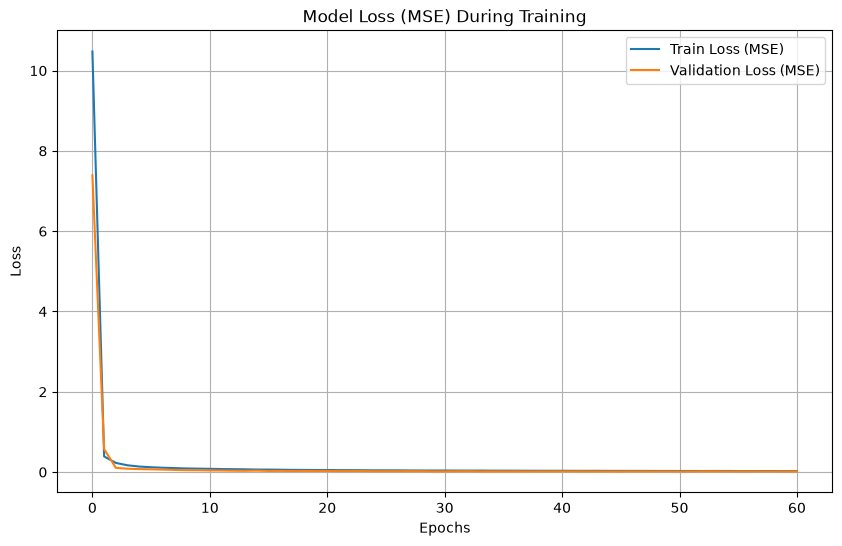

In [24]:
# 셀 5-1: 학습 손실(Loss) 차트 시각화
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss (MSE)')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
plt.title('Model Loss (MSE) During Training')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [25]:
# 셀 6: 모델 평가 (Evaluation)
test_loss = model.evaluate(X_test, y_test, verbose=0)

# 로그 스케일 예측값을 원래 가격 스케일로 복원
y_pred = np.expm1(model.predict(X_test, verbose=0).flatten())
y_actual = np.expm1(y_test.flatten())

test_mae = np.mean(np.abs(y_actual - y_pred))
test_rmse = np.sqrt(np.mean((y_actual - y_pred) ** 2))

print(f"Test MAE (Mean Absolute Error): ${test_mae:.2f}")
print(f"Test RMSE (Root Mean Squared Error): ${test_rmse:.2f}")

Test MAE (Mean Absolute Error): $346.58
Test RMSE (Root Mean Squared Error): $657.53


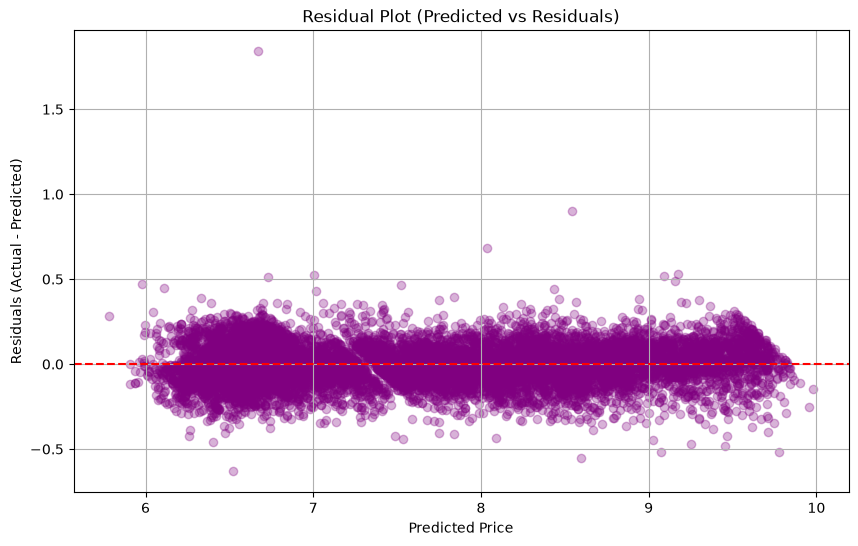

In [27]:
# 셀 7: 잔차(Residual) 그래프 시각화
import matplotlib.pyplot as plt

# 테스트 데이터에 대한 예측값 생성 및 원래 가격 스케일로 복원
y_pred = model.predict(X_test, verbose=0).flatten()
y_actual = y_test.flatten()
residuals = y_actual - y_pred

plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.3, color='purple')
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
plt.title('Residual Plot (Predicted vs Residuals)')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True)
plt.show()